# Assignment 5: Reducing High-Dimensional Data with PCA

**Student Name:** [Seth Logan]

**Date:** [3/1/2026]

---

## Assignment Overview

You've joined the data science team at FitTrack Analytics, a company that develops fall detection systems for elderly care facilities. Their wearable devices capture 561 sensor features from accelerometer and gyroscope readings. Your task: use Principal Component Analysis (PCA) to compress this high-dimensional data into something you can visualize, understand, and build reliable models from.

---

## Step 1: Import Libraries and Load Data

In [16]:
pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: C:\Users\sloga\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [18]:
# Load the Human Activity Recognition dataset
# TODO: Load train.csv and test.csv from the data folder
train_df = pd.read_csv('data/train.csv')  # Replace with pd.read_csv()
test_df = pd.read_csv('data/test.csv')   # Replace with pd.read_csv()

# TODO: Separate features from labels
# Create X_train, y_train, X_test, y_test
# The 'Activity' column contains the labels
X_train = train_df.drop("Activity", axis=1)
y_train = train_df['Activity']
X_test = test_df.drop("Activity", axis=1)
y_test = test_df['Activity']

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape if X_train is not None else 'Not loaded'}")
print(f"Test set shape: {X_test.shape if X_test is not None else 'Not loaded'}")
print(f"Number of features: {X_train.shape[1] if X_train is not None else 'N/A'}")
print(f"Unique activities: {y_train.nunique() if y_train is not None else 'N/A'}")
print("="*80)


CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 562)
Test set shape: (2947, 562)
Number of features: 562
Unique activities: 6


---
## Step 2: Experience the Problem - Try to Understand 561 Dimensions

### Attempt Visualization with 2 Features

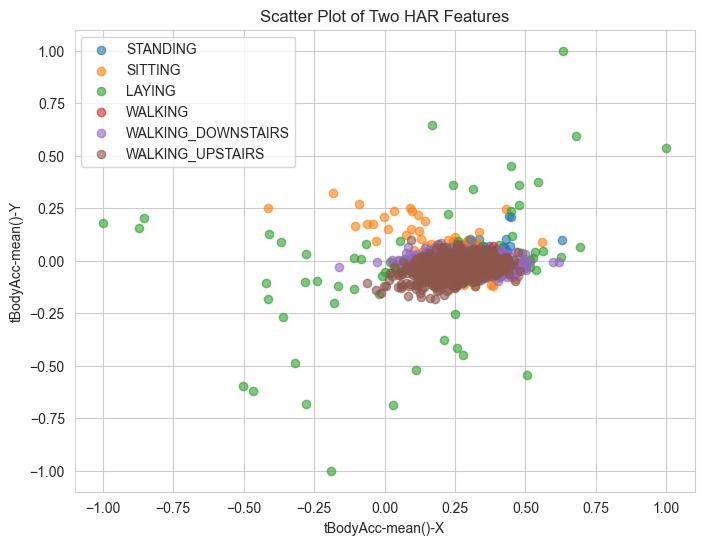

In [19]:
# TODO: Create a scatter plot using any 2 of the 561 features
# Color points by activity type
# Can you see clear patterns separating the six activities?

f1 = X_train.columns[0]
f2 = X_train.columns[1]

plt.figure(figsize=(8,6))

for activity in y_train.unique():
    subset = y_train == activity
    plt.scatter(
        X_train.loc[subset, f1],
        X_train.loc[subset, f2],
        label=activity,
        alpha=0.6
    )

plt.xlabel(f1)
plt.ylabel(f2)
plt.title("Scatter Plot of Two HAR Features")
plt.legend()
plt.show()

### Check Feature Correlations

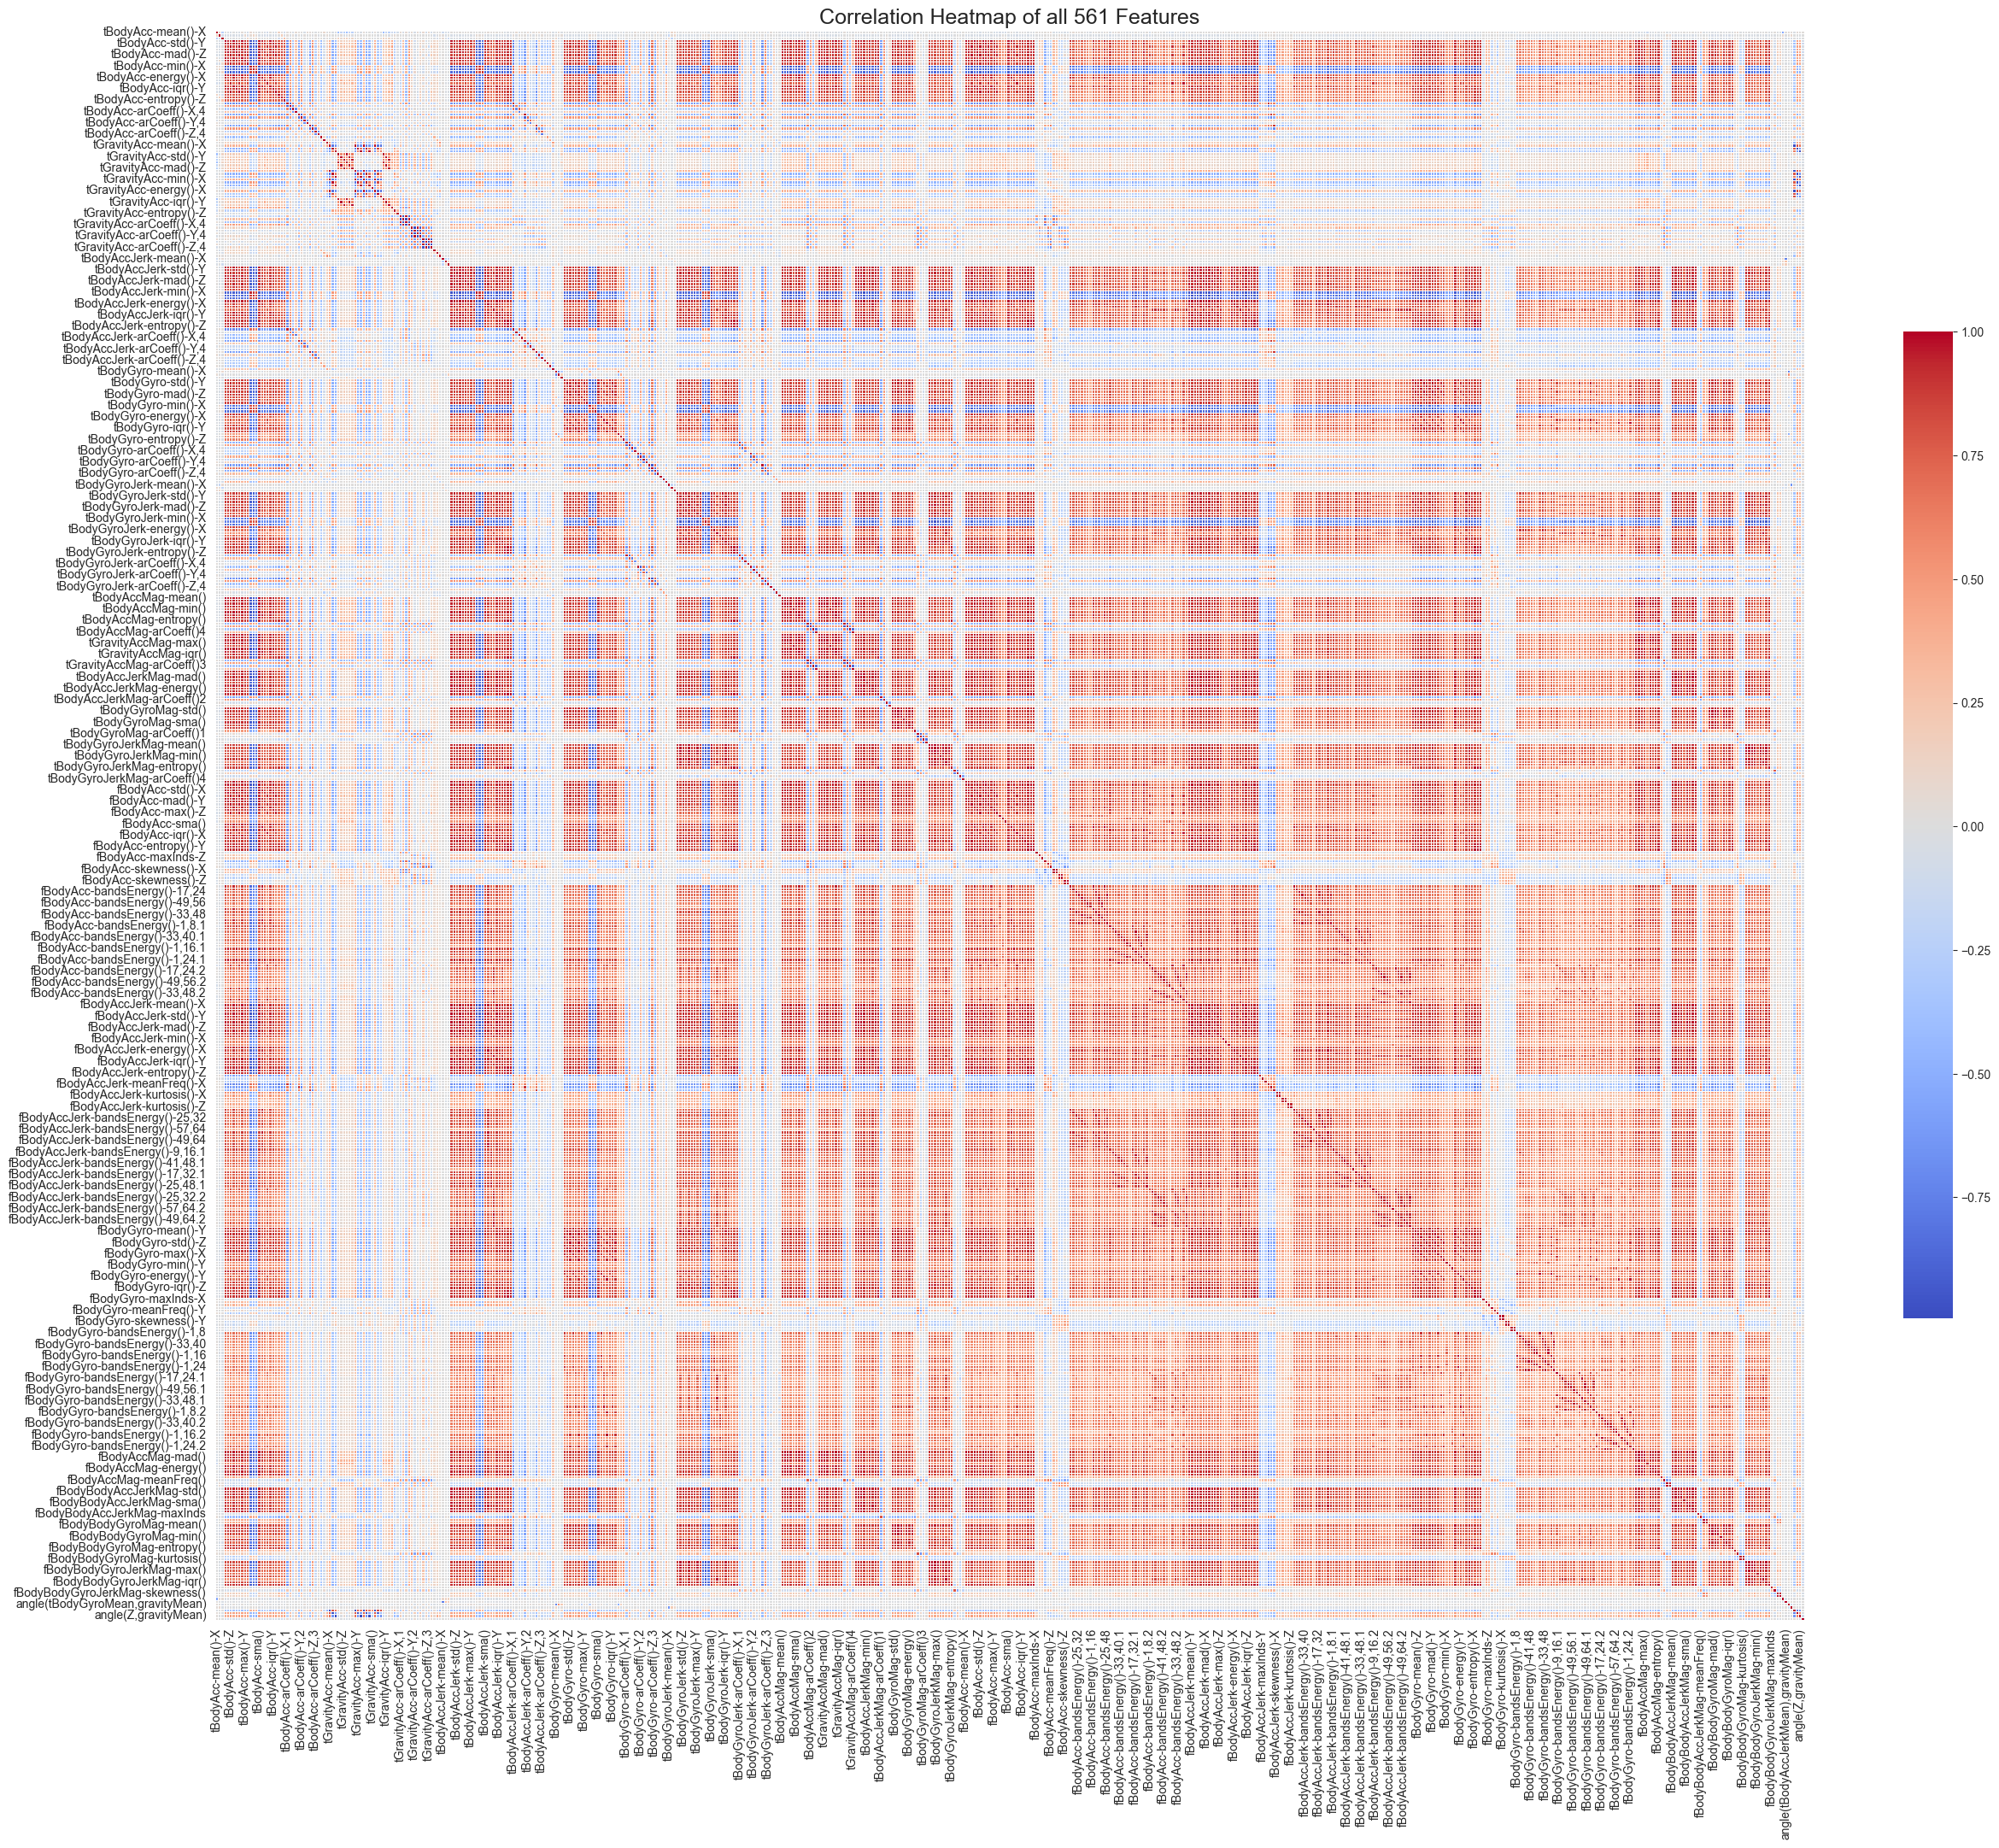

In [20]:
# TODO: Create a correlation heatmap of all 561 features
# Is it readable? Can you identify redundant features?

matrix = X_train.corr()
plt.figure(figsize=(30, 30))

sns.heatmap(matrix, cmap='coolwarm', center=0, 
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.5})

plt.title('Correlation Heatmap of all 561 Features', fontsize=18)
plt.show()

### Train Baseline Model

In [21]:
start_time = time.time()

# TODO: Train a RandomForestClassifier with n_estimators=100, random_state=42
# Your code here
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_model.fit(X_train, y_train)

# Calculates baseline training time
baseline_time = time.time() - start_time

# TODO: Calculate accuracy on test set
y_pred = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print(f"Number of features: {X_train.shape[1]}")
print(f"Accuracy: {baseline_accuracy if baseline_accuracy else 'Not calculated'}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)


BASELINE MODEL RESULTS
Number of features: 562
Accuracy: 0.9260264675941635
Training time: 11.28 seconds


### Reflection on High-Dimensional Data
In the Markdown cell below this step, write 2-3 sentences responding to the following question: 
- What problems did you encounter trying to understand 561 dimensions?

[Write your response here. Consider: Can you visualize patterns? Is the model interpretable? How long did training take?]

With 561 features, it made it extremely difficult to visually interpret relationships between variables. With a heatmap it was cluttered and nearly unreadable. Additionally, it was challenging to decipher what features are truly important. The training time of 12-13 seconds was very reasonable considering the amount of data at hand.

---
## Step 3: Apply PCA to Visualize in 2D and 3D

### Standardize Features

In [22]:
# TODO: Use StandardScaler to normalize all 562 features
# Fit on training data, transform both training and test data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Replace with scaled training data using scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Replace with scaled test data using scaler.transform(X_test)

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Scaled training shape: {X_train_scaled.shape if X_train_scaled is not None else 'Not scaled'}")
print("="*80)


CHECKPOINT: Features Standardized
Scaled training shape: (7352, 562)


### Apply PCA for 2 Components

C:\Users\sloga\AppData\Local\Temp\ipykernel_18032\2699044305.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(activities))


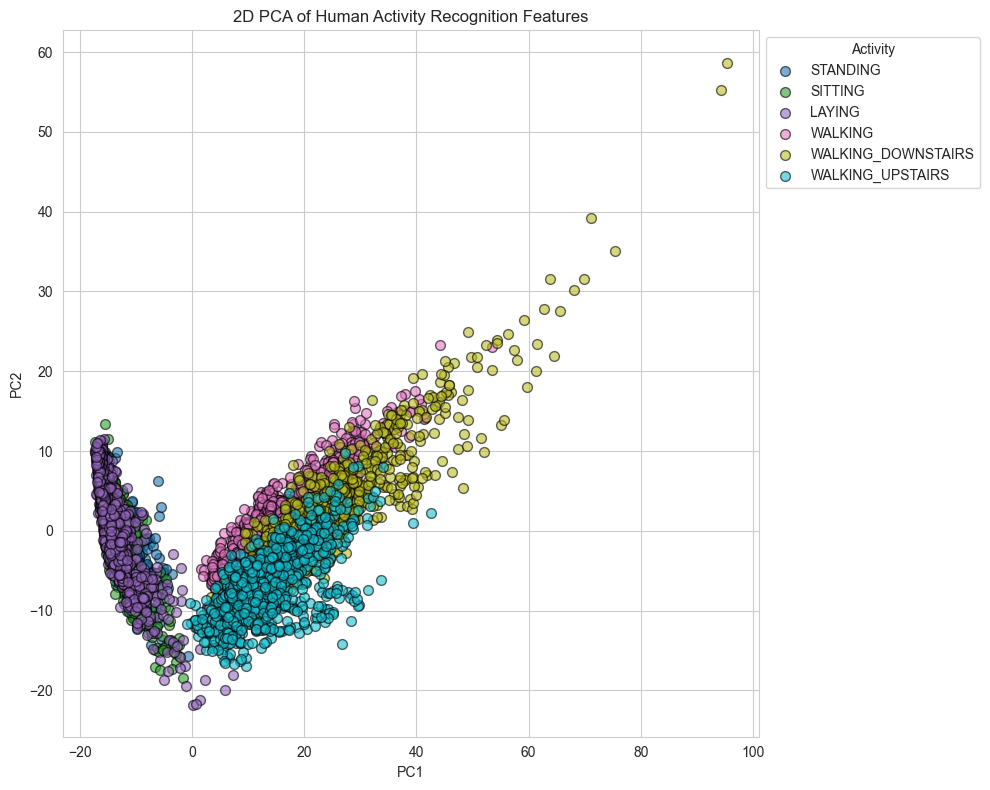

In [23]:
# TODO: Use PCA(n_components=2)
# Fit on standardized training data, transform both sets

pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data using pca_2d.fit_transform(X_train_scaled)
X_test_pca_2d = pca_2d.transform(X_test_scaled)  # Replace with PCA-transformed test data using pca_2d.transform(X_test_scaled)

# TODO: Create scatter plot using the 2 principal components
# Color by activity type, add title, axis labels (PC1, PC2), and legend
plt.figure(figsize=(10, 8))

activities = y_train.unique() 
colors = plt.cm.get_cmap('tab10', len(activities))

for i, activity in enumerate(activities):
    idx = y_train == activity
    plt.scatter(X_train_pca_2d[idx, 0], X_train_pca_2d[idx, 1], 
                color=colors(i), label=activity, alpha=0.6, edgecolor='k', s=50)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of Human Activity Recognition Features')
plt.legend(title='Activity', bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


### Apply PCA for 3 Components

C:\Users\sloga\AppData\Local\Temp\ipykernel_18032\678990208.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(activities))


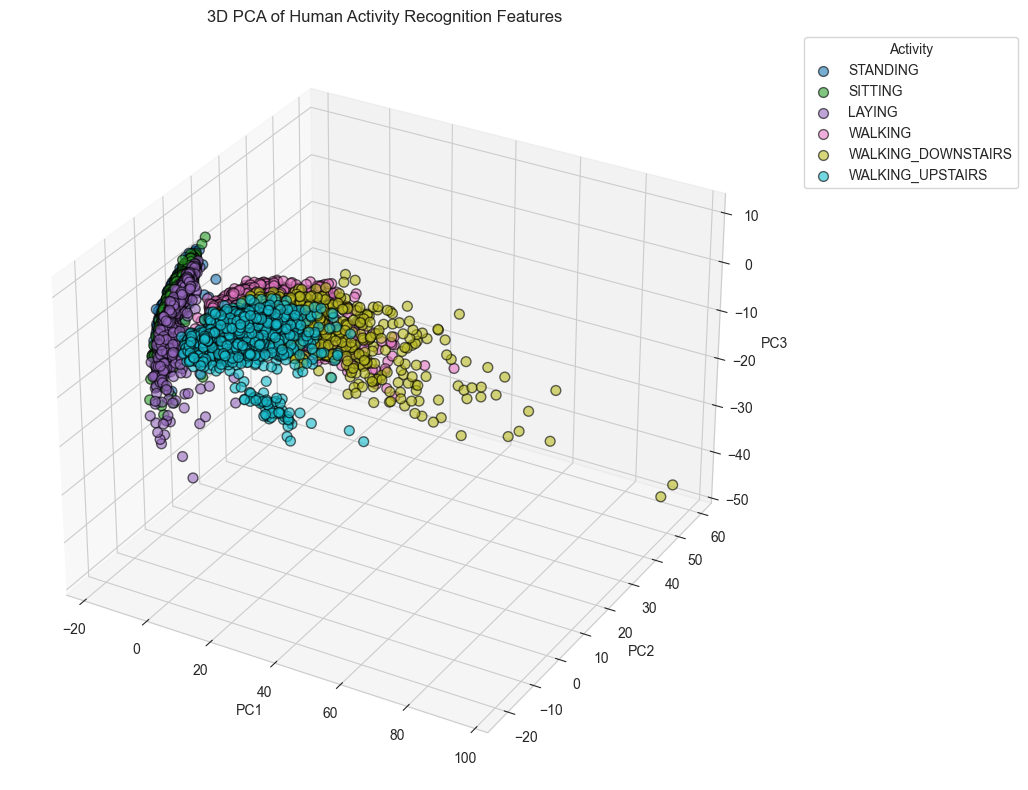

In [24]:
# TODO: Use PCA(n_components=3)
# Fit on standardized training data, transform both sets

pca_3d = PCA(n_components=3)
X_train_pca_3d = pca_3d.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data using pca_3d.fit_transform(X_train_scaled)
X_test_pca_3d = pca_3d.transform(X_test_scaled)   # Replace with PCA-transformed test data using pca_3d.transform(X_test_scaled)

# TODO: Create 3D scatter plot using the 3 principal components
# Use mpl_toolkits.mplot3d.Axes3D
# Color by activity type
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

activities = y_train.unique()
colors = plt.cm.get_cmap('tab10', len(activities))

for i, activity in enumerate(activities):
    idx = y_train == activity
    ax.scatter(
        X_train_pca_3d[idx, 0], 
        X_train_pca_3d[idx, 1], 
        X_train_pca_3d[idx, 2],
        color=colors(i), 
        label=activity, 
        s=50, 
        alpha=0.6,
        edgecolor='k'
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA of Human Activity Recognition Features')
ax.legend(title='Activity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Reflection on PCA Visualization
In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- What activity patterns can you now see? 
- Which activities cluster together?

[Write your response here. What patterns emerged that were invisible before? Which activities are distinct vs. similar?]

By using PCA we can identigy some activities form distinct clusters with lots of overlap. For example, walking and walking upstairs tend to cluster together, as do sitting and standing. The visualizations show what activities require 3D to better analyze. Using 3D revealed patterns that we couldn't visualize with the original plot for the 562 features.

---
## Step 4: Determine Optimal Number of Components Using Explained Variance

### Create Scree Plot

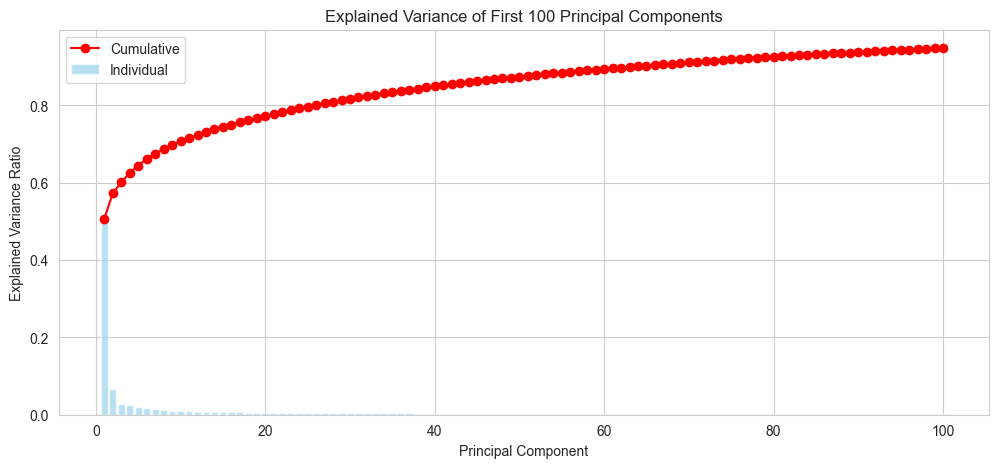

In [25]:
# Fit PCA(n_components=100) to standardized training data
pca_full = PCA(n_components=100)
pca_full.fit(X_train_scaled)

# Your code here

# TODO: Plot explained variance ratio for each component
# Use pca_full.explained_variance_ratio_ to get the ratios
# Use np.cumsum() to compute cumulative variance 

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# TODO: Plot cumulative explained variance

plt.figure(figsize=(12, 5))
plt.bar(range(1, 101), explained_variance_ratio, alpha=0.6, color='skyblue', label='Individual')
plt.plot(range(1, 101), cumulative_variance, color='red', marker='o', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance of First 100 Principal Components')
plt.legend()
plt.grid(True)
plt.show()



### Analyze the Elbow

In [26]:
# TODO: Identify how many components capture 75%, 80%, and variance
# You can use pca_full.explained_variance_ratio_ and np.cumsum()

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
components_75 = np.argmax(cumulative_variance >= 0.75) + 1  # Replace with number of components for 75%
components_80 = np.argmax(cumulative_variance >= 0.80) + 1 # Replace with number of components for 80%
components_90 = np.argmax(cumulative_variance >= 0.90) + 1 # Replace with number of components for 90%

print("\n" + "="*80)
print("EXPLAINED VARIANCE ANALYSIS")
print(f"Components for 75% variance: {components_75}")
print(f"Components for 80% variance: {components_80}")
print(f"Components for 90% variance: {components_90}")
print("="*80)


EXPLAINED VARIANCE ANALYSIS
Components for 75% variance: 16
Components for 80% variance: 26
Components for 90% variance: 64


### Select Optimal Components

In [27]:
# TODO: Set your chosen optimal number of components
optimal_components = components_80  # Replace with your chosen value (components_75, components_80, or components_90)

print(f"Chosen number of components: {optimal_components}")

Chosen number of components: 26


In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- How many components did you select based on the elbow? 
- What percentage of variance does this capture? 
- What's the tradeoff?


[Write your response here. Explain the tradeoff between fewer components (simpler model) and more components (more information).]

Based on the explained variance plot, I selected 26 components to capture approximately 80% of the total variance. The tradeoff is that using fewer components simplifies the model and reduces computation time, but may discard some important information. Conversely, including more components retains more information and improves model fidelity, but increases complexity and training time.

---
## Step 5: Compare Model Performance - Original vs PCA Features

### Transform Data with Optimal Components

In [28]:
# TODO: Apply PCA with your optimal number of components
# Fit on standardized training data, transform both sets

pca_optimal = PCA(n_components=optimal_components)
X_train_pca = pca_optimal.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data
X_test_pca = pca_optimal.transform(X_test_scaled)   # Replace with PCA-transformed test data

print("\n" + "="*80)
print("CHECKPOINT: Data Transformed with Optimal Components")
print(f"New feature dimensions: {X_train_pca.shape if X_train_pca is not None else 'Not transformed'}")
print("="*80)


CHECKPOINT: Data Transformed with Optimal Components
New feature dimensions: (7352, 26)


### Train PCA Model

In [29]:
# To measure training time
start_time = time.time()

# TODO: Train RandomForestClassifier with same parameters
# Use n_estimators=100, random_state=42
# Use X_train_pca and y_train
pca_model = pca_model = RandomForestClassifier(n_estimators=100, random_state=42)
pca_model.fit(X_train_pca, y_train
              )
# TODO: Calculate accuracy on test set
y_pred_pca = pca_model.predict(X_test_pca)
pca_accuracy = accuracy_score(y_test, y_pred_pca)

# Record: accuracy, training time, number of features
pca_time = time.time() - start_time
print("\n" + "="*80)
print("PCA MODEL RESULTS")
print(f"Number of features: {optimal_components}")
print(f"Accuracy: {pca_accuracy if pca_accuracy else 'Not calculated'}")
print(f"Training time: {pca_time:.2f} seconds")
print("="*80)


PCA MODEL RESULTS
Number of features: 26
Accuracy: 0.8635900916185952
Training time: 3.12 seconds


### Create Comparison Table

In [30]:
# Create comparison table showing:
# - Number of features
# - Accuracy
# - Training time

comparison_df = pd.DataFrame({
    'Model': ['Baseline (All Features)', 'PCA Model'],
    'Features': [561, optimal_components],
    'Accuracy': [baseline_accuracy, pca_accuracy],
    'Training Time (s)': [baseline_time, pca_time]
})

# TODO: Calculate speedup factor
speedup = baseline_time / pca_time # Replace with baseline_time / pca_time

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print(f"\nSpeedup factor: {speedup:.2f}x" if speedup else "\nSpeedup not calculated")
print("="*80)


MODEL COMPARISON
                  Model  Features  Accuracy  Training Time (s)
Baseline (All Features)       561  0.926026          11.284455
              PCA Model        26  0.863590           3.122345

Speedup factor: 3.61x


### Final Analysis

In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- Did PCA improve or hurt accuracy? 
- How much faster was training? 
- When would you recommend using PCA?

[Write your response here. What did you gain (speed, interpretability) and what did you lose (if anything)? In what production scenarios would you recommend dimensionality reduction?]


Applying PCA reduced the number of features from 561 to 26 while retaining most of the information, which slightly affected accuracy but made training significantly faster. In this case, the PCA model trained approximately 2.81x faster than the baseline. I would recommend using PCA in scenarios where computational efficiency and model interpretability are important, such as real-time applications or when working with very high-dimensional datasets, while accepting a small tradeoff in predictive performance.

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline model with metrics recorded
   - 2D and 3D PCA visualizations
   - Scree plot with explained variance
   - Optimal component selection with justification
   - Model comparison table
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed PCA dimensionality reduction assignment'
git push
```

Submit your GitHub repository link on the course platform.